# Unsupervised bearing fault detection under operating-condition shift

In [26]:
import os, subprocess, sys
from pathlib import Path
from collections import Counter
import yaml

In [27]:
REPO_URL = 'https://github.com/Syedurehan70/bearing-ae.git'
CONFIG   = 'configs/dense_logspec.yaml'

os.chdir('/kaggle/working')
if not os.path.isdir('bearing-ae'):
    subprocess.run(['git', 'clone', '--quiet', REPO_URL, 'bearing-ae'], check=True)
os.chdir('/kaggle/working/bearing-ae')
subprocess.run(['git', 'fetch', '--quiet', 'origin'], check=True)
subprocess.run(['git', 'reset', '--hard', '--quiet', 'origin/main'], check=True)
print(subprocess.run(['git','log','-1','--oneline'], capture_output=True, text=True).stdout.strip())

4014e61 Update main.py


## 1. Inspecting dataset

In [28]:
mats = sorted(Path('/kaggle/input').rglob('*.mat'))
print(f'{len(mats)} .mat files under /kaggle/input')
for p in mats[:15]:
    print(' ', p)
print('\n')
print(Counter(p.parent.as_posix() for p in mats).most_common(10))

161 .mat files under /kaggle/input
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/100.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/105.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/106.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/107.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/108.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/109.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/110.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/111.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/112.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/118.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/119.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/120.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/121.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/122.mat
  /kaggle/input/datasets/sufian79/cwru-mat-full-dataset/123.mat


[('

## 2. Pointing config at the data

In [29]:
cfg = yaml.safe_load(open(CONFIG))
cfg['data']['roots'] = ['/kaggle/input/datasets/sufian79/cwru-mat-full-dataset']
cfg['data']['exclude'] = [] 
cfg['data']['include'] = []  

run_cfg = '/kaggle/working/config_run.yaml'
yaml.safe_dump(cfg, open(run_cfg, 'w'), sort_keys=False)
print(open(run_cfg).read())

seed: 1337
device: auto
data:
  roots:
  - /kaggle/input/datasets/sufian79/cwru-mat-full-dataset
  channel: DE
  include: []
  exclude: []
  target_rate: 12000
  sample_rate:
    default: 12000
    normal_baseline: 48000
    path_rules:
      48k: 48000
      48khz: 48000
features:
  representation: logspec
  window: 1024
  hop: 128
model:
  kind: dense
  hidden:
  - 128
  - 32
  latent: 8
training:
  epochs: 60
  batch_size: 128
  lr: 0.001
  patience: 8
  min_delta: 1.0e-05
  weight_decay: 1.0e-05
experiment:
  train_load: 1
  calibration_fraction: 0.2
  healthy_test_fraction: 0.2
  threshold_quantile: 0.99
  run_kurtosis_baseline: true



## 3. Training

In [30]:
!python -m src.main --config {run_cfg} --out results

2026-07-23 20:33:25,281 | INFO | device: cpu
2026-07-23 20:33:25,508 | INFO | 
40 runs loaded
label                           samples  source Hz  seconds
ball_0.007_0hp                  122,571     12,000     10.2
ball_0.007_1hp                  121,410     12,000     10.1
ball_0.007_2hp                  121,556     12,000     10.1
ball_0.007_3hp                  121,556     12,000     10.1
ball_0.014_0hp                  121,846     12,000     10.2
ball_0.014_1hp                  122,136     12,000     10.2
ball_0.014_2hp                  121,991     12,000     10.2
ball_0.014_3hp                  122,136     12,000     10.2
ball_0.021_0hp                  121,991     12,000     10.2
ball_0.021_1hp                  121,701     12,000     10.1
ball_0.021_2hp                  122,136     12,000     10.2
ball_0.021_3hp                  122,136     12,000     10.2
inner_race_0.007_0hp            121,265     12,000     10.1
inner_race_0.007_1hp            121,991     12,000     10.2
inner_

## 4. Results


{
  "n_parameters": 140616,
  "n_healthy_train_windows": 564,
  "n_healthy_calibration_windows": 187,
  "n_healthy_test_windows": 187,
  "threshold": 1.214448094367981,
  "epochs_run": 47,
  "same_load": {
    "n_windows": 8692,
    "n_healthy": 187,
    "n_faulty": 8505,
    "false_positive_rate": 0.016042780748663103,
    "true_positive_rate": 1.0,
    "roc_auc": 1.0,
    "average_precision": 0.9999999999999999,
    "recall_by_fault": {
      "ball_0.007_1hp": 1.0,
      "ball_0.014_1hp": 1.0,
      "ball_0.021_1hp": 1.0,
      "inner_race_0.007_1hp": 1.0,
      "inner_race_0.014_1hp": 1.0,
      "inner_race_0.021_1hp": 1.0,
      "outer_race@6_0.007_1hp": 1.0,
      "outer_race@6_0.014_1hp": 1.0,
      "outer_race@6_0.021_1hp": 1.0
    }
  },
  "shifted_load": {
    "n_windows": 27881,
    "n_healthy": 2348,
    "n_faulty": 25533,
    "false_positive_rate": 0.6026405451448041,
    "true_positive_rate": 1.0,
    "roc_auc": 1.0,
    "average_precision": 1.0
  },
  "false_positive_rate

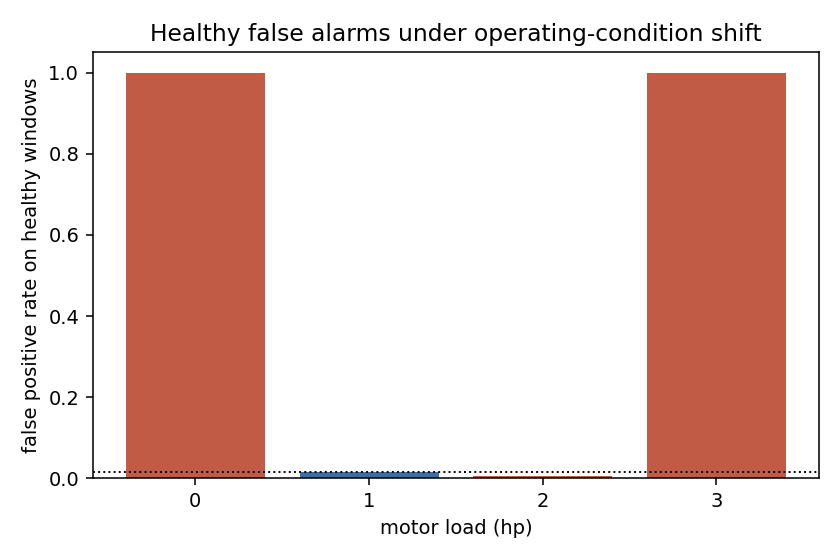

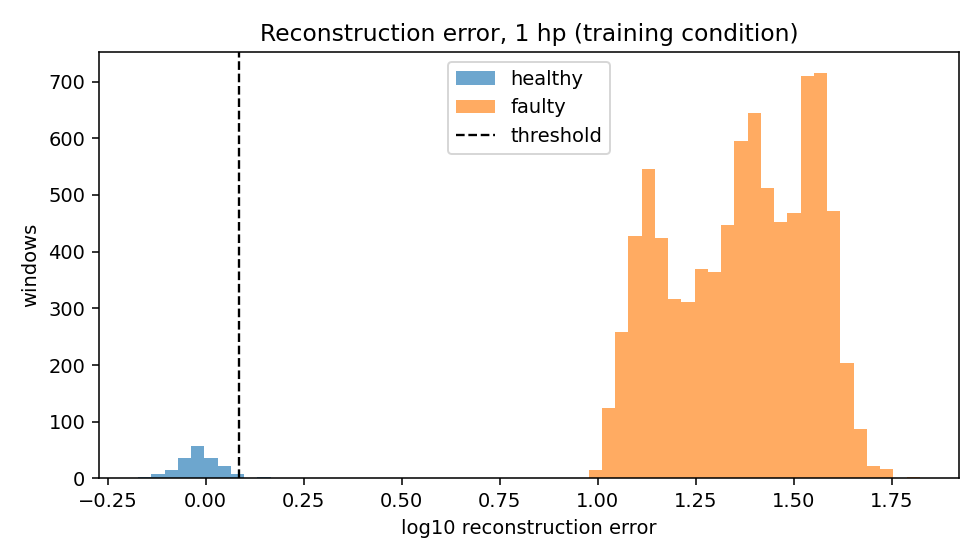

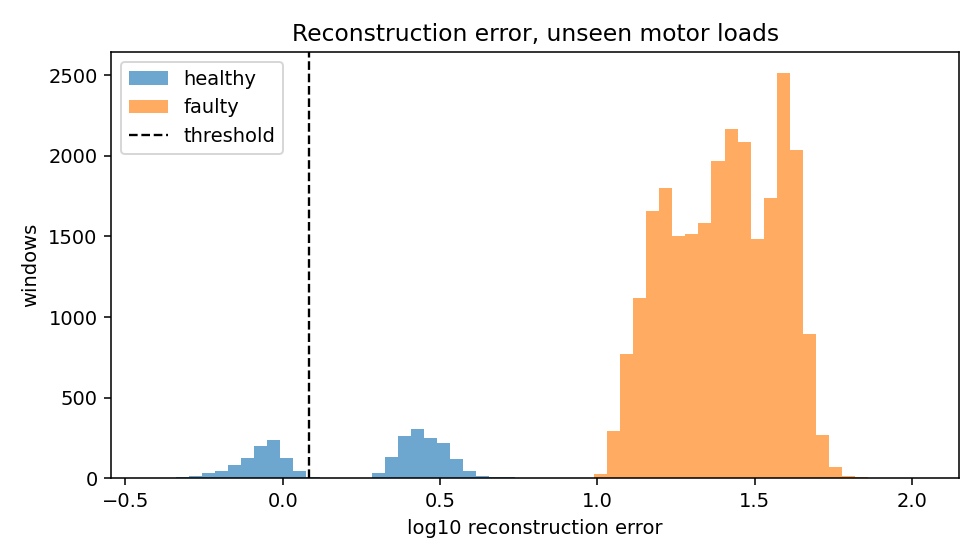

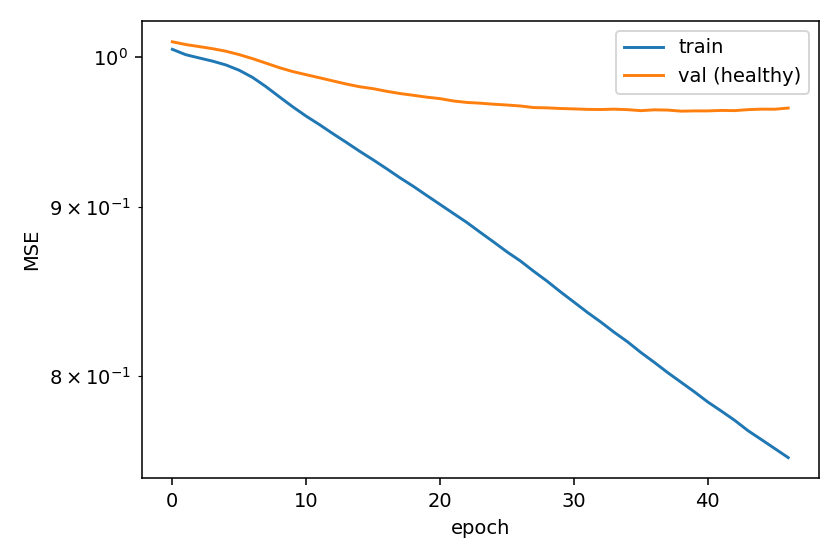

In [32]:
import json
from IPython.display import Image, display

metrics = json.load(open('results/metrics.json'))
print(json.dumps({k: v for k, v in metrics.items() if k != 'config'}, indent=2))

for fig in ['fpr_by_load.png', 'scores_train_load.png', 'scores_shifted_loads.png', 'training_curve.png']:
    path = Path('results') / fig
    if path.exists():
        display(Image(str(path)))


In [35]:
import os
os.chdir('/kaggle/working/bearing-ae')
!zip -qr /kaggle/working/results_new.zip results
print(os.path.getsize('/kaggle/working/results_new.zip'), 'bytes')
!unzip -l /kaggle/working/results.zip

643844 bytes
Archive:  /kaggle/working/results.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2026-07-23 20:32   results/
     2703  2026-07-23 20:33   results/metrics.json
    33077  2026-07-23 20:33   results/fpr_by_load.png
    39065  2026-07-23 20:33   results/scores_train_load.png
    35030  2026-07-23 20:33   results/scores_shifted_loads.png
   567367  2026-07-23 20:33   results/autoencoder.pt
    33365  2026-07-23 20:33   results/training_curve.png
---------                     -------
   710607                     7 files
